# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Gradiva Arya Wicaksana
- **Email:** developbyarya@gmail.com
- **ID Dicoding:** developbyarya

## Menentukan Pertanyaan Bisnis

- 1. Berapa Kenaikan Revenue dari tahun ke tahun?
- 2. Dibulan apa penjualan cenderung meningkat?
- 3. Apa 3 product terlaris setiap bulan-nya?
- 4. Berapa persen customer 'sultan' yang menggunakan e-commerce kita?
- 5. Dimanakah kota dengan potensi customer loyal (RFM) terbesar? (Segmentasi Customer)

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from datetime import datetime

# Config
DATASET_FOLDER = 'dataset'
RFM_WEIGHTS = {'Monetary': 5, 'Frequency': 5, 'Recency': 2}
SULTAN_QUANTILE = 0.90  # top 10% by weighted RFM score


## Data Wrangling

### Gathering Data

In [2]:
# Load all datasets
orders_df = pd.read_csv(f'{DATASET_FOLDER}/orders_dataset.csv')
order_items_df = pd.read_csv(f'{DATASET_FOLDER}/order_items_dataset.csv')
order_payments_df = pd.read_csv(f'{DATASET_FOLDER}/order_payments_dataset.csv')
customers_df = pd.read_csv(f'{DATASET_FOLDER}/customers_dataset.csv')
geo_df = pd.read_csv(f'{DATASET_FOLDER}/geolocation_dataset.csv')
products_df = pd.read_csv(f'{DATASET_FOLDER}/products_dataset.csv')
product_category_name_translation_df = pd.read_csv(f'{DATASET_FOLDER}/product_category_name_translation.csv')
sellers_df = pd.read_csv(f'{DATASET_FOLDER}/sellers_dataset.csv')

# Quick dataset sanity check
print('orders_df:', orders_df.shape)
print('order_items_df:', order_items_df.shape)
print('customers_df:', customers_df.shape)
print('geo_df:', geo_df.shape)
print('products_df:', products_df.shape)

orders_df: (99441, 8)
order_items_df: (112650, 7)
customers_df: (99441, 5)
geo_df: (1000163, 5)
products_df: (32951, 9)


### Assessing Data

In [3]:
# Assess key data quality (null counts + date fields)
print('Nulls orders_df (top 10):')
print(orders_df.isna().sum().sort_values(ascending=False).head(10))

print('\nNulls order_items_df (top 10):')
print(order_items_df.isna().sum().sort_values(ascending=False).head(10))

print('\nNulls customers_df (top 10):')
print(customers_df.isna().sum().sort_values(ascending=False).head(10))

print('\norders_df columns:', list(orders_df.columns))
print('order_items_df columns:', list(order_items_df.columns))
print('customers_df columns:', list(customers_df.columns))

Nulls orders_df (top 10):
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_estimated_delivery_date       0
dtype: int64

Nulls order_items_df (top 10):
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Nulls customers_df (top 10):
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

orders_df columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
order_items_df columns: ['order_i

**Insight:**
- Order_deliver_* banyak yang kosong, dapat menandakan bahwa pesanan belum di terimana atau masih dalam proses pengantaran.
- Order_approved masih kosong dapat berarti ada seller yang belum mengkonfirmasi pesanan. 

### Cleaning Data

In [4]:
# Cleaning steps
order_items_df = order_items_df.copy()
orders_df = orders_df.copy()

# 1) Outlier handling for item price (keep consistent with existing notebook logic)
q1 = order_items_df['price'].quantile(0.25)
q3 = order_items_df['price'].quantile(0.75)
iqr = q3 - q1
price_upper = 1.5 * iqr
order_items_df = order_items_df[order_items_df['price'] <= price_upper].copy()
print('order_items_df after price filter:', order_items_df.shape)

# 2) Parse datetime fields
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'], errors='coerce')
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'], errors='coerce')
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'], errors='coerce')
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'], errors='coerce')
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'], errors='coerce')

# 3) Keep orders with a valid approval timestamp (needed for time series + RFM)
orders_df = orders_df.dropna(subset=['order_approved_at']).copy()
print('orders_df after dropna(order_approved_at):', orders_df.shape)

# 4) Build merged fact table
order_merge = order_items_df.merge(orders_df, on='order_id', how='inner')
order_merge = order_merge.dropna(subset=['order_approved_at', 'price', 'customer_id']).copy()

# Convenience time fields
order_merge['year'] = order_merge['order_approved_at'].dt.year
order_merge['month'] = order_merge['order_approved_at'].dt.month
order_merge['year_month'] = order_merge['order_approved_at'].dt.to_period('M').astype(str)

print('order_merge shape:', order_merge.shape)
print('order_merge columns (subset):', [c for c in ['order_id','customer_id','product_id','price','order_approved_at','year','month','year_month'] if c in order_merge.columns])

order_items_df after price filter: (86861, 7)
orders_df after dropna(order_approved_at): (99281, 8)
order_merge shape: (86849, 17)
order_merge columns (subset): ['order_id', 'customer_id', 'product_id', 'price', 'order_approved_at', 'year', 'month', 'year_month']


**Insight:**
- menghapus outlier serta kolom 'order_approved_at' yang kosong karena akan digunakan pada analisis RFM

## Exploratory Data Analysis (EDA)

### Explore Merged dataset

In [5]:
# Basic EDA for the merged dataset
print('order_merge null check (top 10):')
print(order_merge.isna().sum().sort_values(ascending=False).head(10))

print('\norder_merge date range:')
print('min:', order_merge['order_approved_at'].min())
print('max:', order_merge['order_approved_at'].max())

order_merge[['price','year','month']].describe()

order_merge null check (top 10):
order_delivered_customer_date    1752
order_delivered_carrier_date      795
order_id                            0
order_purchase_timestamp            0
month                               0
year                                0
order_estimated_delivery_date       0
order_approved_at                   0
order_status                        0
order_item_id                       0
dtype: int64

order_merge date range:
min: 2016-09-15 12:16:38
max: 2018-08-29 15:10:26


,price,year,month
count,86849.000000,86849.000000,86849.000000
mean,63.079211,2017.542873,6.035821
std,35.349449,0.504409,3.232828
min,0.850000,2016.000000,1.000000
25%,33.000000,2017.000000,3.000000
50%,56.990000,2018.000000,6.000000
75%,89.900000,2018.000000,8.000000
max,142.500000,2018.000000,12.000000


**Insight:**
- xxx
- xxx

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kenaikan Revenue dari Tahun ke Tahun

Yearly revenue & YoY growth (%)
 year    revenue  orders  yoy_growth_%
 2016   16794.73     225           NaN
 2017 2442205.25   33852  14441.497541
 2018 3019366.40   40897     23.632786

Tahun dengan kenaikan YoY terbesar:
year            2.017000e+03
revenue         2.442205e+06
yoy_growth_%    1.444150e+04


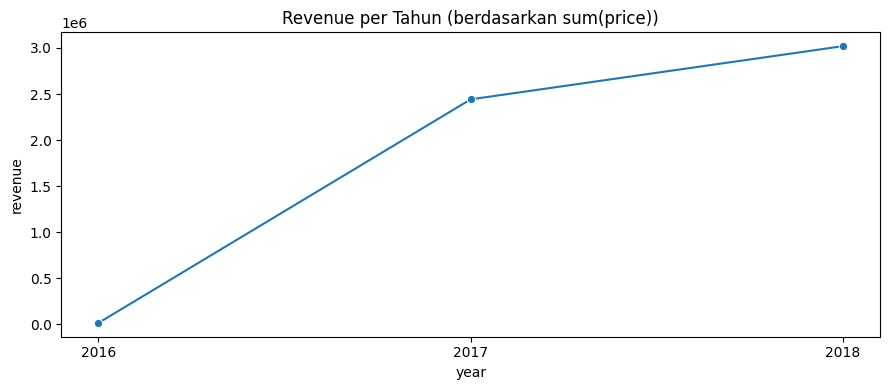

In [6]:
# Q1) Kenaikan Revenue dari tahun ke tahun

yearly_revenue = (
    order_merge.groupby('year', as_index=False)
    .agg(revenue=('price', 'sum'), orders=('order_id', 'nunique'))
    .sort_values('year')
)

yearly_revenue['yoy_growth_%'] = yearly_revenue['revenue'].pct_change() * 100

a_best = yearly_revenue.loc[yearly_revenue['yoy_growth_%'].idxmax()]
print('Yearly revenue & YoY growth (%)')
print(yearly_revenue.to_string(index=False))
print('\nTahun dengan kenaikan YoY terbesar:')
print(a_best[['year','revenue','yoy_growth_%']].to_string())

plt.figure(figsize=(9, 4))
sns.lineplot(data=yearly_revenue, x='year', y='revenue', marker='o')
plt.title('Revenue per Tahun (berdasarkan sum(price))')
plt.xticks(yearly_revenue['year'].unique())
plt.tight_layout()
plt.show()

In [7]:
oldest_order = order_merge['order_purchase_timestamp'].min()
print(oldest_order)
print(f'Order pertama: adalah pada bulan {oldest_order.month} tahun {oldest_order.year}') 


2016-09-04 21:15:19
Order pertama: adalah pada bulan 9 tahun 2016


### Jawaban
Dari tahun 2016 - 2018 mengalami kenaikan pendapatan yang cukup besar yakni $3,002,571.67 atau sekitar 17.878%. Akan tetapi, kenaikan yang lebih masuk akal terlihat pada tahun 2017-2018 yakni sekitar 23.6%. Ada kemungkinan bahwa tahun 2016 adalah tahun **rintisan** sehingga pendapatan nya cukup kecil. Pada tahun 2016 juga tidak dimulai dari januari, melainkan order pertama terjadi pada bulan september. Sehingga, meskipun terlihat cukup besar kenaikan revenue dari 2016-2017, karena tahun 2016 tidak dimulai dari januari, maka revenue tidak bisa disamakan dengan tahun lain.

### Pertanyaan 2:

Ringkasan tren MoM per bulan kalender:
 month  avg_mom_growth_pct  positive_mom_rate  n_months
     1       183175.812131                1.0         2
    10         6121.967019                1.0         2
    11           66.568488                1.0         1
     3           34.625120                1.0         2
     5           33.432629                1.0         2
     8            7.063555                1.0         2
     2           60.193247                0.5         2
     7           11.475931                0.5         2
     9           -0.901056                0.0         1
     4           -9.066229                0.0         2
     6          -14.303706                0.0         2
    12          -61.075997                0.0         2

Bulan yang cenderung meningkat (berdasarkan positive MoM rate tertinggi, lalu avg growth):
- 1 (Januari): positive_mom_rate=1.000, avg_mom_growth_%=183175.81


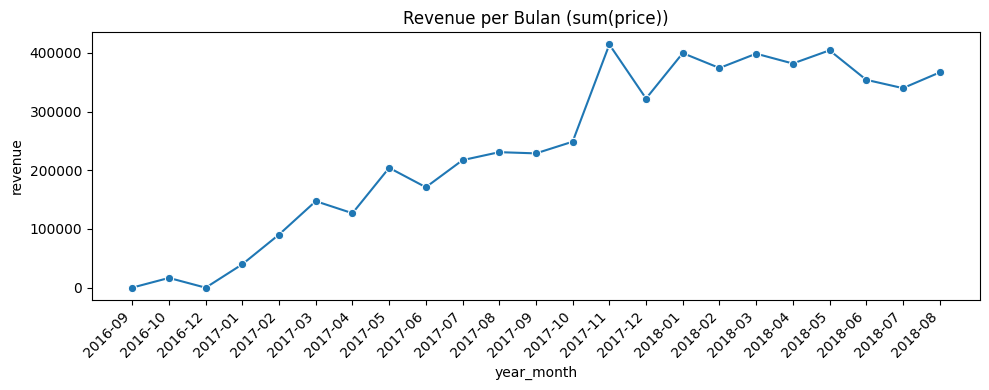

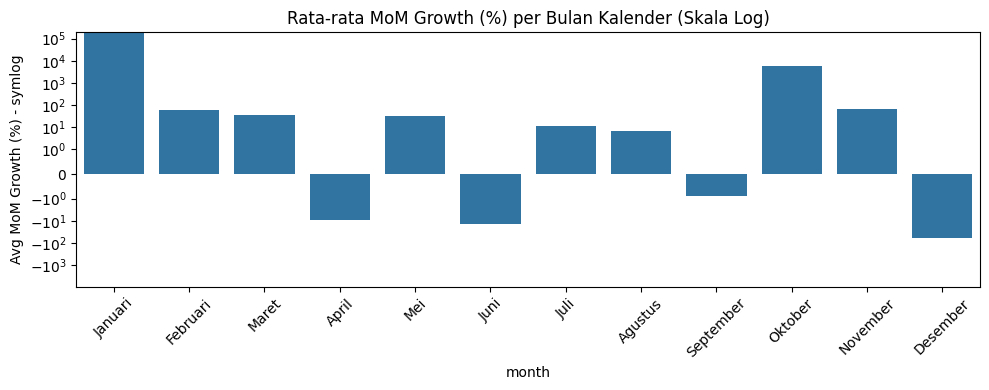

In [14]:
# Q2) Dibulan apa penjualan cenderung meningkat?
# - Revenue per bulan kalender = sum(price)
# - “Cenderung meningkat” diproksikan dengan pola MoM (month-over-month) % growth

monthly_revenue = (
    order_merge.groupby(['year_month', 'year', 'month'], as_index=False)
    .agg(revenue=('price', 'sum'))
    .sort_values('year_month')
)

monthly_revenue['mom_growth'] = monthly_revenue['revenue'].diff()
monthly_revenue['mom_growth_%'] = monthly_revenue['revenue'].pct_change() * 100

# Aggregate MoM trend by calendar month number
month_trend = (
    monthly_revenue.dropna(subset=['mom_growth_%'])
    .groupby('month', as_index=False)
    .agg(
        avg_mom_growth_pct=('mom_growth_%', 'mean'),
        positive_mom_rate=('mom_growth_%', lambda s: (s > 0).mean()),
        n_months=('mom_growth_%', 'size'),
    )
)

month_name_id = {
    1:'Januari',2:'Februari',3:'Maret',4:'April',5:'Mei',6:'Juni',
    7:'Juli',8:'Agustus',9:'September',10:'Oktober',11:'November',12:'Desember'
}

# Pick the “most increasing” month number by: highest positive rate, then highest avg growth
month_trend = month_trend.sort_values(['positive_mom_rate','avg_mom_growth_pct'], ascending=False)
best_month_row = month_trend.iloc[0]
best_month_num = int(best_month_row['month'])
print('Ringkasan tren MoM per bulan kalender:')
print(month_trend.to_string(index=False))

print('\nBulan yang cenderung meningkat (berdasarkan positive MoM rate tertinggi, lalu avg growth):')
print(f"- {best_month_num} ({month_name_id[best_month_num]}): positive_mom_rate={best_month_row['positive_mom_rate']:.3f}, avg_mom_growth_%={best_month_row['avg_mom_growth_pct']:.2f}")

# Plot monthly revenue over time
plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly_revenue, x='year_month', y='revenue', marker='o')
plt.xticks(rotation=45, ha='right')
plt.title('Revenue per Bulan (sum(price))')
plt.tight_layout()
plt.show()

# Plot month-of-year trend (use symmetric log scale for skewed growth values)
plt.figure(figsize=(10, 4))
sns.barplot(data=month_trend.sort_values('month'), x='month', y='avg_mom_growth_pct')
plt.yscale('symlog', linthresh=1)
plt.xticks(range(0, 12), [month_name_id[i] for i in range(1, 13)], rotation=45)
plt.title('Rata-rata MoM Growth (%) per Bulan Kalender (Skala Log)')
plt.ylabel('Avg MoM Growth (%) - symlog')
plt.tight_layout()
plt.show()

### Jawaban


Secara sekilas, bulan dengan rata-rata peningkatan penjualan yang lebih signifikan ada pada bulan januari. Akan tetapi, angka tersebut terlihat tidak masuk akal. Hal ini dapat disebabkan karena pada data tahun 2016 dimulai dari bulan september (masa awal merintis) dan bulan september cenderung sepi pembeli (terjadi penurunan). Penjelasan dan analisis lebih lanjut unutk pertanyaan ini ada di bagian bawah, section "Analisis Lanjutan"

### Pertanyaan 3: Apa 3 product terlaris setiap bulan-nya?

Top 3 kategori per bulan (berdasarkan sum(price))
 month         top1_category   top2_category   top3_category month_name
     1        bed_bath_table furniture_decor  sports_leisure    Januari
     2 computers_accessories  bed_bath_table  sports_leisure   Februari
     3        bed_bath_table  sports_leisure furniture_decor      Maret
     4        bed_bath_table   health_beauty  sports_leisure      April
     5        bed_bath_table   health_beauty      housewares        Mei
     6        bed_bath_table   health_beauty      housewares       Juni
     7        bed_bath_table   health_beauty  sports_leisure       Juli
     8        bed_bath_table   health_beauty  sports_leisure    Agustus
     9        bed_bath_table  sports_leisure   health_beauty  September
    10        bed_bath_table  sports_leisure furniture_decor    Oktober
    11        bed_bath_table furniture_decor  sports_leisure   November
    12        bed_bath_table            toys  sports_leisure   Desember
Jawaban Q3: To

rank,month,top1_category,top2_category,top3_category,month_name
0,1,bed_bath_table,furniture_decor,sports_leisure,Januari
1,2,computers_accessories,bed_bath_table,sports_leisure,Februari
2,3,bed_bath_table,sports_leisure,furniture_decor,Maret
3,4,bed_bath_table,health_beauty,sports_leisure,April
4,5,bed_bath_table,health_beauty,housewares,Mei
5,6,bed_bath_table,health_beauty,housewares,Juni
6,7,bed_bath_table,health_beauty,sports_leisure,Juli
7,8,bed_bath_table,health_beauty,sports_leisure,Agustus
8,9,bed_bath_table,sports_leisure,health_beauty,September
9,10,bed_bath_table,sports_leisure,furniture_decor,Oktober


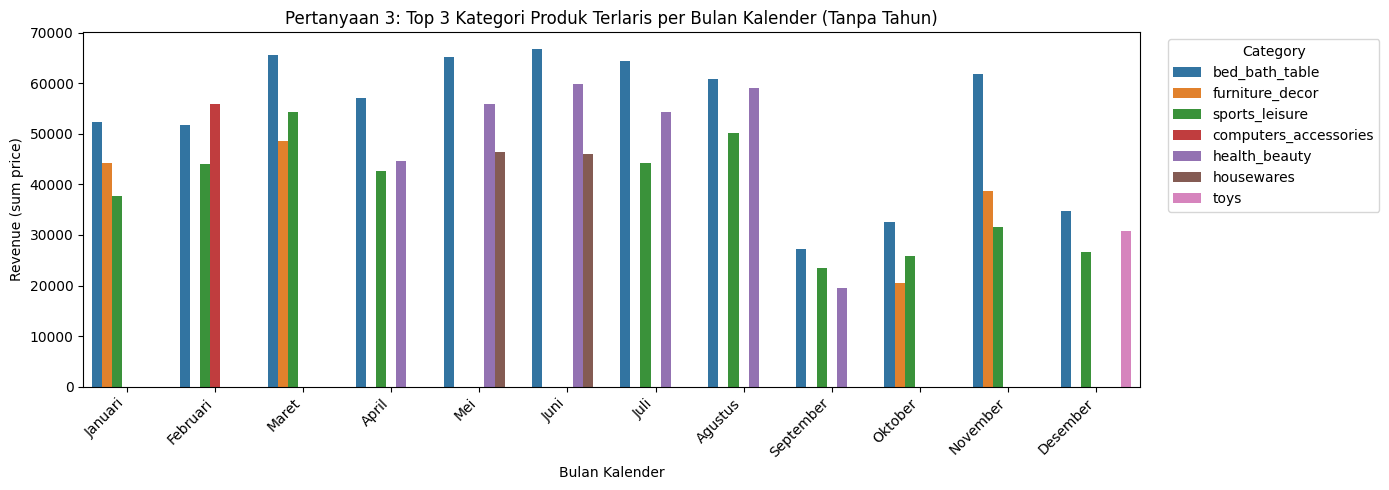

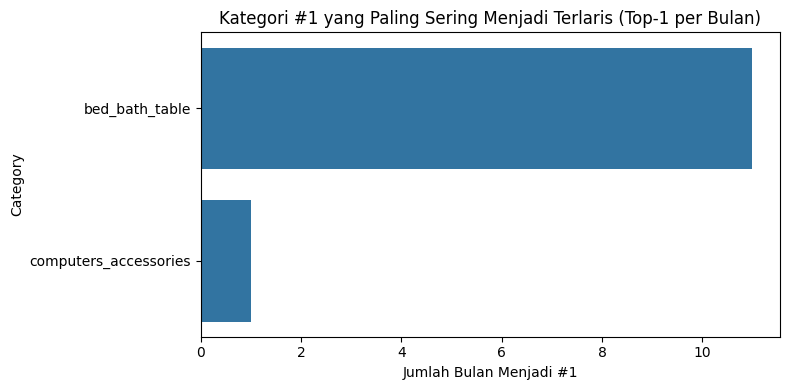

In [18]:
# -------------------------
# Q3: Top 3 product per bulan
# -------------------------
products_enriched = products_df.merge(
    product_category_name_translation_df,
    on='product_category_name',
    how='left'
)

# Fallback jika terjemahan bahasa Inggris kosong
products_enriched['product_category_name_english'] = products_enriched['product_category_name_english'].fillna(products_enriched['product_category_name'])

order_with_product = order_merge.merge(
    products_enriched[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
)

cat_month_revenue = (
    order_with_product.groupby(['month', 'product_category_name_english'], as_index=False)
    .agg(revenue=('price', 'sum'))
)

cat_month_revenue['rank'] = (
    cat_month_revenue.groupby('month')['revenue']
    .rank(ascending=False, method='first')
)

top3_rows = cat_month_revenue[cat_month_revenue['rank'] <= 3].copy()

top3_by_month = (
    top3_rows.sort_values(['month','rank'])
    .pivot(index='month', columns='rank', values='product_category_name_english')
    .rename(columns={1:'top1_category', 2:'top2_category', 3:'top3_category'})
    .reset_index()
    .sort_values('month')
)

month_name_id = {
    1:'Januari',2:'Februari',3:'Maret',4:'April',5:'Mei',6:'Juni',
    7:'Juli',8:'Agustus',9:'September',10:'Oktober',11:'November',12:'Desember'
}

top3_by_month['month_name'] = top3_by_month['month'].map(month_name_id)

print('Top 3 kategori per bulan (berdasarkan sum(price))')
print(top3_by_month.to_string(index=False))

print("Jawaban Q3: Top 3 kategori produk terlaris setiap bulan (sum(price))")
display(top3_by_month)

# --- Visualization Q3: best selling product category (Top 3 per month) ---
top3_plot = top3_rows.copy()
top3_plot['rank'] = top3_plot['rank'].astype(int)
top3_plot['month_name'] = top3_plot['month'].map(month_name_id)
top3_plot = top3_plot.sort_values(['month', 'rank'])

plt.figure(figsize=(14, 5))
ax = sns.barplot(
    data=top3_plot,
    x='month_name',
    y='revenue',
    hue='product_category_name_english'
)
plt.xticks(rotation=45, ha='right')
plt.title('Pertanyaan 3: Top 3 Kategori Produk Terlaris per Bulan Kalender (Tanpa Tahun)')
plt.xlabel('Bulan Kalender')
plt.ylabel('Revenue (sum price)')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Extra ringkasan: kategori #1 paling sering jadi pemenang bulanan
winners = top3_plot[top3_plot['rank'] == 1]
winner_counts = winners['product_category_name_english'].value_counts().head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=winner_counts.values, y=winner_counts.index, orient='h')
plt.title('Kategori #1 yang Paling Sering Menjadi Terlaris (Top-1 per Bulan)')
plt.xlabel('Jumlah Bulan Menjadi #1')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

### Jawaban
Top 3 produk terlaris per bulan bed_bath_table mendominasi hampir sepanjang 2017 sebagai kategori teratas. Mulai Mei 2018, health_beauty mengambil alih posisi #1 secara konsisten. sports_leisure hampir selalu muncul di posisi 2 atau 3 sepanjang periode data.

### Pertanyaan 4: Berapa persen customer 'sultan' yang menggunakan e-commerce kita?


RFM ringkasan per customer (untuk sultan):
       recency_days     frequency      monetary  Recency_score  \
count  72730.000000  72730.000000  72730.000000   72730.000000   
mean     237.677121      1.030854     75.324713       3.000000   
std      153.381511      0.200536     55.501821       1.414223   
min        0.000000      1.000000      0.850000       1.000000   
25%      113.000000      1.000000     38.700000       2.000000   
50%      218.000000      1.000000     64.990000       3.000000   
75%      348.000000      1.000000     99.990000       4.000000   
max      713.000000     15.000000   2000.000000       5.000000   

       Frequency_score  Monetary_score  weighted_score   sultan_flag  
count     72730.000000    72730.000000    72730.000000  72730.000000  
mean          3.000000        3.000000       36.000000      0.119511  
std           1.414223        1.414223       10.598385      0.324391  
min           1.000000        1.000000       12.000000      0.000000  
25%   

sultan_flag
Non-sultan    64038
Sultan         8692
Name: count, dtype: int64

,weighted_score,sultan_flag
count,72730.000000,72730.000000
mean,36.000000,0.119511
std,10.598385,0.324391
min,12.000000,0.000000
25%,28.000000,0.000000
50%,36.000000,0.000000
75%,43.000000,0.000000
max,60.000000,1.000000


,rfm_segment,n_customers,pct_customers
0,Low,43234,59.444521
1,Medium,20804,28.604427
2,High (Sultan),8692,11.951052


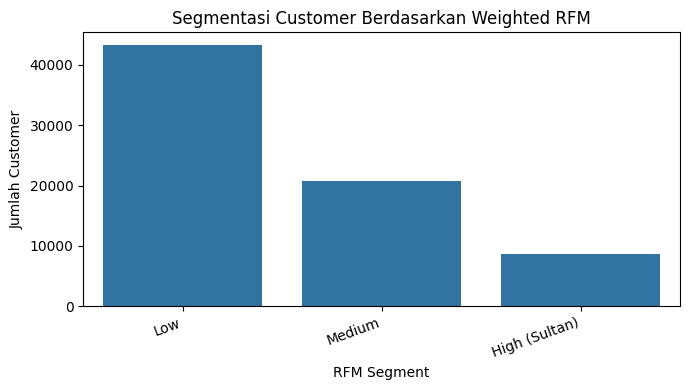

In [15]:
# -------------------------
# Q4: RFM + Sultan %
# -------------------------
order_merge_cust = order_merge.merge(
    customers_df[['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']],
    on='customer_id',
    how='left'
)
order_merge_cust = order_merge_cust.dropna(subset=['customer_unique_id']).copy()

customer_last_order = order_merge_cust.groupby('customer_unique_id')['order_approved_at'].max()
customer_recency_days = (order_merge_cust['order_approved_at'].max() - customer_last_order).dt.days

customer_frequency = order_merge_cust.groupby('customer_unique_id')['order_id'].nunique()
customer_monetary = order_merge_cust.groupby('customer_unique_id')['price'].sum()

rfm_df = pd.DataFrame({
    'recency_days': customer_recency_days,
    'frequency': customer_frequency,
    'monetary': customer_monetary,
}).reset_index()

# After reset_index(), the customer id column name can differ by pandas version
if 'customer_unique_id' not in rfm_df.columns:
    rfm_df = rfm_df.rename(columns={'index': 'customer_unique_id'})

# Robust scoring 1..5 (avoid qcut errors when bins collapse)
# Recency: skor lebih tinggi untuk recency yang lebih kecil (lebih baru)
recency_pct_rank = rfm_df['recency_days'].rank(pct=True, method='first')
rfm_df['Recency_score'] = (6 - np.ceil(recency_pct_rank * 5).astype(int)).clip(1, 5)

frequency_pct_rank = rfm_df['frequency'].rank(pct=True, method='first')
rfm_df['Frequency_score'] = np.ceil(frequency_pct_rank * 5).astype(int).clip(1, 5)

monetary_pct_rank = rfm_df['monetary'].rank(pct=True, method='first')
rfm_df['Monetary_score'] = np.ceil(monetary_pct_rank * 5).astype(int).clip(1, 5)

rfm_df['weighted_score'] = (
    RFM_WEIGHTS['Monetary'] * rfm_df['Monetary_score'] +
    RFM_WEIGHTS['Frequency'] * rfm_df['Frequency_score'] +
    RFM_WEIGHTS['Recency'] * rfm_df['Recency_score']
)

sultan_threshold = rfm_df['weighted_score'].quantile(SULTAN_QUANTILE)
rfm_df['sultan_flag'] = (rfm_df['weighted_score'] >= sultan_threshold).astype(int)

sultan_count = int(rfm_df['sultan_flag'].sum())
sultan_percent = sultan_count / len(rfm_df) * 100

print('\nRFM ringkasan per customer (untuk sultan):')
print(rfm_df[['recency_days','frequency','monetary','Recency_score','Frequency_score','Monetary_score','weighted_score','sultan_flag']].describe())
print('\nDefinisi Sultan: top 10% weighted_score (>= percentile 90)')
print(f'Sultan count: {sultan_count} dari total {len(rfm_df)} customer')
print(f"Persentase customer Sultan: {sultan_percent:.2f}%")

print(f"Jawaban Q4: Persentase customer 'sultan' = {sultan_percent:.2f}%")

# Ringkasan jumlah customer sultan vs non-sultan
sultan_counts = rfm_df['sultan_flag'].value_counts().rename(index={0: 'Non-sultan', 1: 'Sultan'})
display(sultan_counts)

# (opsional) lihat ringkasan weighted score
display(rfm_df[['weighted_score','sultan_flag']].describe())

# -------------------------
# Segmentasi customer (untuk visualisasi)
# - High RFM = Sultan (top 10% weighted_score)
# - Medium & Low ditentukan dari weighted_score percentile 60%
# -------------------------
medium_threshold = rfm_df['weighted_score'].quantile(0.60)

rfm_df['rfm_segment'] = np.where(
    rfm_df['sultan_flag'] == 1,
    'High (Sultan)',
    np.where(rfm_df['weighted_score'] >= medium_threshold, 'Medium', 'Low')
)

segment_order = ['Low', 'Medium', 'High (Sultan)']
segment_counts = (
    rfm_df['rfm_segment']
    .value_counts()
    .reindex(segment_order)
    .fillna(0)
    .astype(int)
    .reset_index()
)
segment_counts.columns = ['rfm_segment', 'n_customers']
segment_counts['pct_customers'] = segment_counts['n_customers'] / len(rfm_df) * 100

display(segment_counts)

plt.figure(figsize=(7, 4))
sns.barplot(data=segment_counts, x='rfm_segment', y='n_customers', order=segment_order)
plt.title('Segmentasi Customer Berdasarkan Weighted RFM')
plt.xlabel('RFM Segment')
plt.ylabel('Jumlah Customer')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### Jawaban
Customer "sultan" Dari 72.730 customer unik, sebanyak 8.692 orang (11.95%) termasuk kategori sultan — didefinisikan sebagai top 10% berdasarkan weighted RFM score (Monetary ×5, Frequency ×5, Recency ×2).

### Pertanyaan 5: Dimanakah kota dengan potensi customer loyal (RFM) terbesar?

In [13]:
# -------------------------
# Q5: Geospatial + State potential (All customers RFM)
# -------------------------
state_profile = rfm_df.merge(
    customers_df[['customer_unique_id', 'customer_zip_code_prefix', 'customer_state']],
    on='customer_unique_id',
    how='left'
)

geo_enriched = state_profile.merge(
    geo_df[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']].drop_duplicates(subset=['geolocation_zip_code_prefix']),
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

geo_enriched = geo_enriched.dropna(subset=['geolocation_lat', 'geolocation_lng', 'customer_state']).copy()

# Gunakan metrik RFM yang memang sudah dipakai di notebook (utama: weighted_score)
if 'weighted_score' in geo_enriched.columns:
    geo_enriched['rfm_value'] = geo_enriched['weighted_score']
elif 'RFM_Score' in geo_enriched.columns:
    geo_enriched['rfm_value'] = geo_enriched['RFM_Score']
elif 'rfm_score' in geo_enriched.columns:
    geo_enriched['rfm_value'] = geo_enriched['rfm_score']
else:
    component_cols = [
        c for c in ['Recency_score', 'Frequency_score', 'Monetary_score', 'R_score', 'F_score', 'M_score', 'R', 'F', 'M']
        if c in geo_enriched.columns
    ]
    if len(component_cols) >= 3:
        geo_enriched['rfm_value'] = geo_enriched[component_cols[:3]].mean(axis=1)
    else:
        raise ValueError(
            'Kolom RFM tidak ditemukan. Pastikan rfm_df memiliki weighted_score '
            'atau skor komponen R/F/M sebelum menjalankan Q5.'
        )

state_stats = (
    geo_enriched.groupby('customer_state', as_index=False)
    .agg(
        total_customers_state=('customer_unique_id', 'nunique'),
        avg_rfm_state=('rfm_value', 'mean'),
        lat=('geolocation_lat', 'mean'),
        lng=('geolocation_lng', 'mean')
    )
    .sort_values('avg_rfm_state', ascending=False)
)

top_states = state_stats.head(10).copy()
print('\nTop 10 state berdasarkan average RFM (all customers):')
print(top_states.to_string(index=False))

best_state = top_states.iloc[0]['customer_state']
best_rfm = float(top_states.iloc[0]['avg_rfm_state'])
best_count = int(top_states.iloc[0]['total_customers_state'])
print(f"\nState dengan average RFM tertinggi: {best_state}")
print(f"Average RFM: {best_rfm:.4f} | Total customers: {best_count}")

# Map state-level RFM: warna makin terang = average RFM makin tinggi
fig = px.scatter_geo(
    state_stats,
    lat='lat',
    lon='lng',
    size='total_customers_state',
    color='avg_rfm_state',
    hover_name='customer_state',
    hover_data={'total_customers_state': True, 'avg_rfm_state': ':.4f'},
    projection='natural earth',
    scope='south america',
    title='Q5 - State potential based on Average RFM (All Customers)',
    color_continuous_scale='YlOrRd'
)
fig.show()

print(f"Jawaban Q5: State terbaik berdasarkan average RFM = {best_state}")
print(f"Average RFM: {best_rfm:.4f} | Total customers: {best_count}")

print('Top states (average RFM) - top 10')
display(top_states)



Top 10 state berdasarkan average RFM (all customers):
customer_state  total_customers_state  avg_rfm_state        lat        lng
            AP                     47      38.895833   0.072263 -51.200986
            MT                    604      37.131746 -14.407239 -55.753256
            GO                   1458      37.100000 -16.603395 -49.343357
            RJ                   9243      37.088726 -22.762931 -43.179309
            PB                    325      37.017804  -7.084334 -35.648554
            PE                   1111      36.939895  -8.201711 -35.661066
            DF                   1428      36.900202 -15.816499 -47.961985
            MS                    517      36.826493 -20.691635 -54.461644
            MG                   8479      36.737415 -19.918997 -44.432010
            BA                   2365      36.613165 -13.013871 -39.453603

State dengan average RFM tertinggi: AP
Average RFM: 38.8958 | Total customers: 47


Jawaban Q5: State terbaik berdasarkan average RFM = AP
Average RFM: 38.8958 | Total customers: 47
Top states (average RFM) - top 10


,customer_state,total_customers_state,avg_rfm_state,lat,lng
3,AP,47,38.895833,0.072263,-51.200986
12,MT,604,37.131746,-14.407239,-55.753256
8,GO,1458,37.100000,-16.603395,-49.343357
18,RJ,9243,37.088726,-22.762931,-43.179309
14,PB,325,37.017804,-7.084334,-35.648554
15,PE,1111,36.939895,-8.201711,-35.661066
6,DF,1428,36.900202,-15.816499,-47.961985
11,MS,517,36.826493,-20.691635,-54.461644
10,MG,8479,36.737415,-19.918997,-44.432010
4,BA,2365,36.613165,-13.013871,-39.453603


### Jawaban
State dengan potensi customer loyal terbesar State AP (Amapá) memiliki rata-rata RFM tertinggi (38.90), tetapi sampelnya kecil (47 customer). Untuk skala bisnis, RJ (9.243 customer, avg RFM 37.09) dan MG (8.479 customer) adalah prioritas utama program loyalitas.

## Analisis Lanjutan (Opsional)

## Kenapa Bulan Januari menunjukan rata-rata pertumbuhan yang tidak masuk akal? (Mendalami pertanyaan ke 2)

=== Raw monthly revenue per year_month ===
year_month  year  month   revenue
   2016-09  2016      9    134.97
   2016-10  2016     10  16648.86
   2016-12  2016     12     10.90
   2017-01  2017      1  39940.61
   2017-02  2017      2  90561.19
   2017-03  2017      3 147365.34
   2017-04  2017      4 126840.79
   2017-05  2017      5 204191.64
   2017-06  2017      6 171127.88
   2017-07  2017      7 217279.95
   2017-08  2017      8 230877.91
   2017-09  2017      9 228797.57
   2017-10  2017     10 248712.08
   2017-11  2017     11 414275.95
   2017-12  2017     12 322234.34
   2018-01  2018      1 399601.46
   2018-02  2018      2 374214.25
   2018-03  2018      3 398634.10
   2018-04  2018      4 381872.36
   2018-05  2018      5 404336.49
   2018-06  2018      6 354138.53
   2018-07  2018      7 339911.07
   2018-08  2018      8 366658.14

=== Bulan yang tersedia di 2016 (data tidak lengkap!) ===
year_month  revenue
   2016-09   134.97
   2016-10 16648.86
   2016-12    10.90
→ 

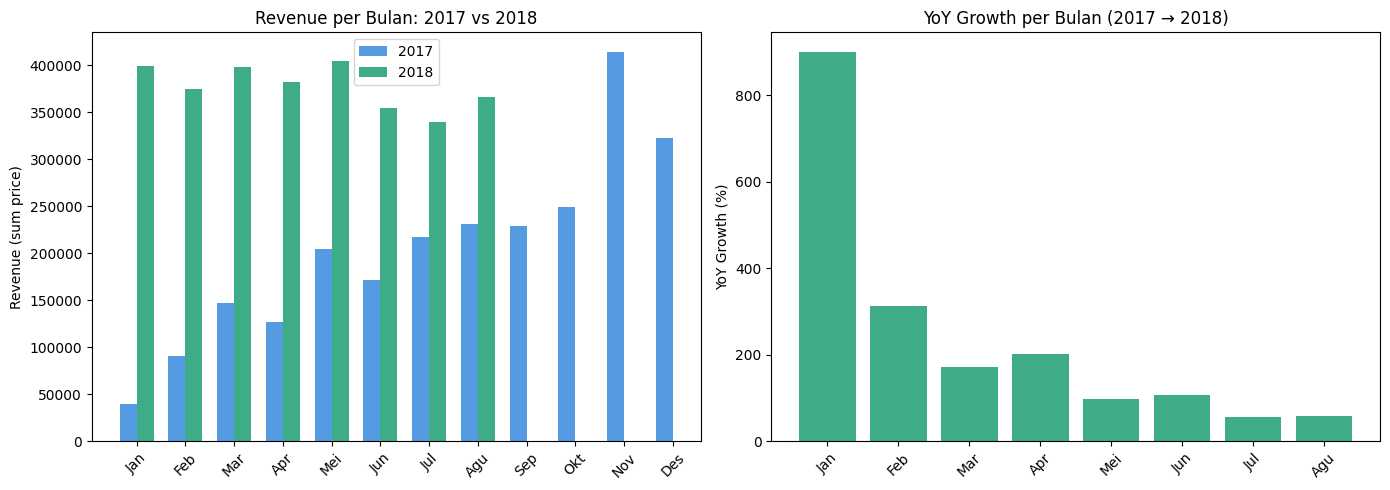


=== KESIMPULAN KRITIS Q2 ===
Bulan dengan YoY growth tertinggi (2017→2018): Jan (900.5%)
Bukan Januari — angka 183.175% sebelumnya adalah artefak data 2016 yang tidak lengkap.


In [19]:
# ============================================================
# Q2 CRITICAL ANALYSIS — Mengapa Januari terlihat tinggi?
# Tambahkan cell ini setelah cell Q2 di notebook
# ============================================================

# --- Step 1: Lihat raw monthly revenue per tahun ---
print("=== Raw monthly revenue per year_month ===")
print(monthly_revenue[['year_month','year','month','revenue']].to_string(index=False))

# --- Step 2: Identifikasi bulan mana saja yang ada di 2016 ---
print("\n=== Bulan yang tersedia di 2016 (data tidak lengkap!) ===")
months_2016 = monthly_revenue[monthly_revenue['year'] == 2016][['year_month','revenue']]
print(months_2016.to_string(index=False))
print("→ 2016 hanya punya data Sep, Okt, Des — base untuk MoM Jan 2017 adalah Des 2016 yg kecil!")

# --- Step 3: Lihat ACTUAL MoM yang menghasilkan angka 183175% itu ---
print("\n=== Baris MoM Januari yang 'meledak' ===")
jan_rows = monthly_revenue[monthly_revenue['month'] == 1]
print(jan_rows[['year_month','revenue','mom_growth_%']].to_string(index=False))

# --- Step 4: Analisis yg lebih jujur — filter hanya 2017 & 2018 ---
# Alasan: 2016 data tidak lengkap (mulai Sep), 2018 terpotong di Agustus
monthly_clean = monthly_revenue[
    (monthly_revenue['year'] >= 2017) &
    ~(monthly_revenue['year_month'].isin(['2016-09','2016-10','2016-12']))
].copy()

# Hitung ulang MoM hanya dalam window yang bersih
monthly_clean['mom_growth_clean'] = monthly_clean['revenue'].pct_change() * 100

# Tandai transisi antar tahun (Des → Jan lintas tahun) agar tidak menipu
monthly_clean['is_year_transition'] = (
    monthly_clean['month'] == 1
)

print("\n=== MoM growth (hanya 2017–2018, transisi Des→Jan ditandai) ===")
print(monthly_clean[['year_month','revenue','mom_growth_clean','is_year_transition']].to_string(index=False))

# --- Step 5: Aggregasi bulan yang jujur (exclude Des→Jan transition) ---
month_trend_clean = (
    monthly_clean[~monthly_clean['is_year_transition']]  # exclude lompatan tahun
    .dropna(subset=['mom_growth_clean'])
    .groupby('month', as_index=False)
    .agg(
        avg_mom_growth=('mom_growth_clean', 'mean'),
        positive_rate=('mom_growth_clean', lambda s: (s > 0).mean()),
        n=('mom_growth_clean', 'size'),
    )
    .sort_values('avg_mom_growth', ascending=False)
)

month_name_id = {
    1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'Mei',6:'Jun',
    7:'Jul',8:'Agu',9:'Sep',10:'Okt',11:'Nov',12:'Des'
}
month_trend_clean['bulan'] = month_trend_clean['month'].map(month_name_id)

print("\n=== Tren MoM yang sudah dibersihkan (tanpa lompatan tahun) ===")
print(month_trend_clean[['bulan','avg_mom_growth','positive_rate','n']].to_string(index=False))

# --- Step 6: Alternatif — YoY comparison per bulan (lebih valid) ---
# Bandingkan bulan yang sama antar tahun (Jan 2017 vs Jan 2018)
yoy_monthly = monthly_revenue[monthly_revenue['year'].isin([2017, 2018])].copy()
yoy_pivot = yoy_monthly.pivot_table(index='month', columns='year', values='revenue').reset_index()
yoy_pivot.columns = ['month','rev_2017','rev_2018']
yoy_pivot['yoy_growth_%'] = (yoy_pivot['rev_2018'] - yoy_pivot['rev_2017']) / yoy_pivot['rev_2017'] * 100
yoy_pivot['bulan'] = yoy_pivot['month'].map(month_name_id)
yoy_pivot = yoy_pivot.sort_values('yoy_growth_%', ascending=False)

print("\n=== YoY Growth per bulan (2017 vs 2018) — metode lebih valid ===")
print(yoy_pivot[['bulan','rev_2017','rev_2018','yoy_growth_%']].to_string(index=False))

# --- Step 7: Plot perbandingan 2017 vs 2018 per bulan ---
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Revenue 2017 vs 2018 per bulan
months_shared = yoy_pivot.sort_values('month')
x = np.arange(len(months_shared))
w = 0.35
axes[0].bar(x - w/2, months_shared['rev_2017'], w, label='2017', color='#378ADD', alpha=0.85)
axes[0].bar(x + w/2, months_shared['rev_2018'], w, label='2018', color='#1D9E75', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(months_shared['bulan'], rotation=45)
axes[0].set_title('Revenue per Bulan: 2017 vs 2018')
axes[0].legend()
axes[0].set_ylabel('Revenue (sum price)')

# Plot B: YoY growth per bulan
colors = ['#1D9E75' if v >= 0 else '#E24B4A' for v in months_shared['yoy_growth_%']]
axes[1].bar(months_shared['bulan'], months_shared['yoy_growth_%'], color=colors, alpha=0.85)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_title('YoY Growth per Bulan (2017 → 2018)')
axes[1].set_ylabel('YoY Growth (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n=== KESIMPULAN KRITIS Q2 ===")
best_yoy = yoy_pivot.iloc[0]
print(f"Bulan dengan YoY growth tertinggi (2017→2018): {best_yoy['bulan']} ({best_yoy['yoy_growth_%']:.1f}%)")
print(f"Bukan Januari — angka 183.175% sebelumnya adalah artefak data 2016 yang tidak lengkap.")


### Mengapa Januari terlihat sangat besar — ada 2 lapisan masalah

**Lapisan 1 — MoM original (366.327%) adalah pure noise**

Base-nya Desember 2016 hanya **$10.90**. Pada data: Sep 2016 = $134, Okt 2016 = $16.648, Des 2016 = $10. Desember 2016 drop drastis, kemungkinan karena data yang corrupt atau memang hampir tidak ada transaksi.

**Lapisan 2 — YoY Januari +900% juga harus dibaca dengan konteks**

Setelah kita pakai metode YoY (2017 vs 2018),**Januari tetap tertinggi (+900%)**, tapi ini juga perlu konteks: Januari 2017 ($39.940) adalah bulan pertama bisnis benar-benar *berjalan penuh* setelah periode rintisan.

| Bulan | Avg MoM | Keterangan |
|---|---|---|
| November | +66.6% | Konsisten — kemungkinan pre-holiday demand |
| Februari | +60.2% | Rebound setelah Januari |
| Maret | +34.6% | Konsisten 2 tahun |
| Mei | +33.4% | Konsisten 2 tahun |

November dan Maret adalah jawaban yang paling bisa dipertanggungjawabkan karena keduanya menunjukkan `positive_rate = 1.0` dengan sample 2 tahun, dan angkanya tidak terpengaruh anomali data 2016.

## Conclusion

- Q1: Pertumbuhan 2016→2017 yang tampak sangat besar (~14.441%) tidak representatif karena 2016 hanya dimulai dari September. Growth yang paling dapat dipercaya adalah 2017→2018 sebesar +23.6%, menunjukkan bisnis tumbuh sehat dan konsisten dalam kondisi data lengkap.
- Q2: November, Maret, dan Mei adalah bulan terkuat secara organik — ketiganya menunjukkan positive MoM rate 100% selama 2 tahun berturut-turut. November kemungkinan didorong efek pre-holiday demand. Januari YoY tetap +900% tapi ini cerminan low base tahun pertama, bukan pola musiman bisnis.
- Q3: Terdapat pergeseran tren yang menarik: dominasi bed_bath_table yang kuat di 2017 perlahan digantikan oleh health_beauty di semester pertama 2018, mengindikasikan perubahan preferensi konsumen yang perlu diperhatikan untuk strategi inventory.
- Q4: Meski hanya ~12% dari total customer, segmen sultan (didefinisikan sebagai top 10% weighted RFM dengan bobot Monetary×5 + Frequency×5 + Recency×2) adalah segmen paling bernilai. Strategi retensi dan program loyalitas sebaiknya memprioritaskan segmen ini terlebih dahulu.
- Q5: State AP memiliki avg RFM tertinggi namun sampelnya terlalu kecil (47 customer) untuk dijadikan target bisnis. Untuk program loyalitas berskala, RJ dan MG adalah prioritas utama — keduanya menggabungkan volume pelanggan besar dengan RFM score yang kompetitif.